# Notebook 23: Population Health Data & Survival Analysis

**BINF 4002 — Machine Learning for Health** | Lecture 23 Companion

This notebook generates figures for Lecture 23, which has two parts:

**Part I — Population Health Data:** registries, biobanks, and clinical trials. Running example: kidney stone treatment comparison (Charig et al., 1986).

**Part II — Survival Analysis:** a modeling technique for time-to-event outcomes, common in this domain and many others.

### Main Figures
| # | Description | Data source | Slide status |
|---|-------------|-------------|---|
| 1 | NHANES variable structure & missingness | Real NHANES 2017–2018 | Main deck |
| — | Simpson's Paradox in NHANES (leg length vs HDL) | Real NHANES 2017–2018 | Main deck |
| — | Simpson's Paradox in Palmer Penguins | seaborn built-in | Enrichment |
| 3 | Kaplan-Meier: population + stratified by sex | lifelines VA Lung Cancer | Main deck |
| 4 | Cox PH forest plot + Schoenfeld diagnostics | lifelines GBSG2 | Main deck |

### Appendix Figures
| # | Description | Data source |
|---|-------------|-------------|
| 5 | DeepSurv vs. Cox C-index | lifelines GBSG2 |
| 6 | Propensity score adjustment | Simulated (ground truth required) |
| 7 | Kidney stone Simpson's Paradox | Real Charig et al. (1986) data |

**All data is real** except the propensity score demo (which requires known ground truth by design).


In [1]:
# ============================================================
# Install Dependencies (run once)
# ============================================================
# (pip install handled by the book's isolated env)


/bin/bash: line 1: pip: command not found


In [2]:
# ============================================================
# Setup & Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import requests
import io

warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 11,
})

# Columbia palette
COLUMBIA = "#1D4F91"
ACCENT = "#D2492A"
GRAY = "#757575"
GREEN = "#2E8B57"
LIGHT_BG = "#F5F5FA"


In [3]:
# ============================================================
# Load lifelines built-in datasets
# ============================================================
from lifelines.datasets import load_lung, load_gbsg2, load_rossi

# NCCTG Lung Cancer: 228 patients, survival data with sex and other covariates
lung = load_lung()
print(f"NCCTG Lung Cancer: {lung.shape[0]} patients, {lung.shape[1]} variables")
print(lung.head(3))
print()

# GBSG2: German Breast Cancer Study Group RCT, 686 patients
gbsg2 = load_gbsg2()
print(f"GBSG2: {gbsg2.shape[0]} patients, {gbsg2.shape[1]} variables")
print(gbsg2.head(3))


NCCTG Lung Cancer: 228 patients, 10 variables
   inst  time  status  age  sex  ph.ecog  ph.karno  pat.karno  meal.cal  \
0   3.0   306       1   74    1      1.0      90.0      100.0    1175.0   
1   3.0   455       1   68    1      0.0      90.0       90.0    1225.0   
2   3.0  1010       0   56    1      0.0      90.0       90.0       NaN   

   wt.loss  
0      NaN  
1     15.0  
2     15.0  

GBSG2: 686 patients, 10 variables
  horTh  age menostat  tsize tgrade  pnodes  progrec  estrec  time  cens
0    no   70     Post     21     II       3       48      66  1814     1
1   yes   56     Post     12     II       7       61      77  2018     1
2   yes   58     Post     35     II       9       52     271   712     1


In [4]:
# ============================================================
# Load NHANES Data (real data from CDC)
# ============================================================
# Downloads Demographics (DEMO), Blood Pressure (BPX), Body Measures (BMX),
# Lab data (multiple files), and Questionnaire data from 2017-2018 cycle.
# Works in any non-sandboxed environment (local Python, standard Colab).
# Falls back to synthetic if the CDC server is unreachable.

import io
import requests
import pandas as pd

# Using the direct data URL path which bypasses WAF blocks
NHANES_BASE = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/"

# Files to download — chosen to give a rich set of variables with
# interesting missingness structure (fasting subsamples, age-gating, etc.)
NHANES_FILES = {
    "DEMO":   "DEMO_J.xpt",    # Demographics (complete for all)
    "BMX":    "BMX_J.xpt",     # Body measures (age >= 2)
    "BPX":    "BPX_J.xpt",     # Blood pressure (age >= 8, 3 readings)
    "GHB":    "GHB_J.xpt",     # Glycohemoglobin / HbA1c (age >= 12)
    "GLU":    "GLU_J.xpt",     # Fasting glucose (fasting subsample only)
    "TRIGLY": "TRIGLY_J.xpt",  # Triglycerides (fasting subsample)
    "TCHOL":  "TCHOL_J.xpt",   # Total cholesterol
    "HDL":    "HDL_J.xpt",     # HDL cholesterol
    "ALQ":    "ALQ_J.xpt",     # Alcohol use questionnaire (age >= 18)
    "SMQ":    "SMQ_J.xpt",     # Smoking questionnaire
    "PAQ":    "PAQ_J.xpt",     # Physical activity
    "DPQ":    "DPQ_J.xpt",     # Depression screener (age >= 12)
    "SLQ":    "SLQ_J.xpt",     # Sleep disorders
    "MCQ":    "MCQ_J.xpt",     # Medical conditions
    "DIQ":    "DIQ_J.xpt",     # Diabetes
    "DR1TOT": "DR1TOT_J.xpt", # Dietary recall day 1 totals
}

# Columns to keep from each file (to avoid overwhelming width)
KEEP_COLS = {
    "DEMO":   ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "DMDEDUC2",
               "DMDMARTL", "INDFMPIR", "WTMEC2YR"],
    "BMX":    ["SEQN", "BMXWT", "BMXHT", "BMXBMI", "BMXWAIST", "BMXLEG", "BMXARML"],
    "BPX":    ["SEQN", "BPXSY1", "BPXDI1", "BPXSY2", "BPXDI2", "BPXSY3", "BPXDI3"],
    "GHB":    ["SEQN", "LBXGH"],
    "GLU":    ["SEQN", "LBXGLU"],
    "TRIGLY": ["SEQN", "LBXTR"],
    "TCHOL":  ["SEQN", "LBXTC"],
    "HDL":    ["SEQN", "LBDHDD"],
    "ALQ":    ["SEQN", "ALQ130"],
    "SMQ":    ["SEQN", "SMQ020"],
    "PAQ":    ["SEQN", "PAQ605", "PAQ650"],
    "DPQ":    ["SEQN", "DPQ010", "DPQ020", "DPQ030"],
    "SLQ":    ["SEQN", "SLQ050", "SLQ060"],
    "MCQ":    ["SEQN", "MCQ010", "MCQ160A", "MCQ160B", "MCQ160C"],
    "DIQ":    ["SEQN", "DIQ010"],
    "DR1TOT": ["SEQN", "DR1TKCAL", "DR1TPROT", "DR1TFAT", "DR1TCARB"],
}

nhanes_dfs = {}
failed = []

headers = {'User-Agent': 'Mozilla/5.0'}

for name, fname in NHANES_FILES.items():
    url = NHANES_BASE + fname
    try:
        r = requests.get(url, headers=headers, timeout=30)
        r.raise_for_status()

        # Verify it does not look like HTML
        if b"<!DOCTYPE html>" in r.content[:100].lower() or b"<html" in r.content[:100].lower():
            raise ValueError("Received HTML instead of binary XPT file. The CDC is actively blocking Colab's IP.")

        df = pd.read_sas(io.BytesIO(r.content), format='xport')

        # Keep only selected columns
        cols_to_keep = [c for c in KEEP_COLS.get(name, []) if c in df.columns]
        nhanes_dfs[name] = df[cols_to_keep] if cols_to_keep else df
        print(f"  ✓ {name}: {nhanes_dfs[name].shape[0]} rows, {nhanes_dfs[name].shape[1]} cols")
    except Exception as e:
        failed.append(name)
        print(f"  ✗ {name}: {e}")

if len(failed) == 0:
    # Merge all on SEQN
    nhanes = nhanes_dfs["DEMO"]
    for name in list(NHANES_FILES.keys())[1:]:
        nhanes = nhanes.merge(nhanes_dfs[name], on="SEQN", how="left")
    NHANES_LOADED = True
    print(f"\nMerged real NHANES: {nhanes.shape[0]} participants, {nhanes.shape[1]} variables")
    pct_miss = nhanes.drop(columns=["SEQN"]).isnull().mean().sort_values(ascending=False)
    print(f"Missingness range: {pct_miss.min():.1%} to {pct_miss.max():.1%} ({pct_miss.idxmax()})")
    print(f"\nVariables with >20% missing (protocol-driven):")
    for col, rate in pct_miss[pct_miss > 0.20].items():
        print(f"  {col}: {rate:.1%}")
else:
    print(f"\n{len(failed)}/{len(NHANES_FILES)} NHANES files failed to download.")
    print("The CDC's firewall appears to be blocking automated requests from Google Colab.")

if 'nhanes' in locals():
    print(f"\nFirst 3 rows:")
    print(nhanes.head(3).to_string())


  ✓ DEMO: 9254 rows, 8 cols


  ✓ BMX: 8704 rows, 7 cols
  ✓ BPX: 8704 rows, 7 cols


  ✓ GHB: 6401 rows, 2 cols
  ✓ GLU: 3036 rows, 2 cols


  ✓ TRIGLY: 3036 rows, 2 cols
  ✓ TCHOL: 7435 rows, 2 cols


  ✓ HDL: 7435 rows, 2 cols
  ✓ ALQ: 5533 rows, 2 cols


  ✓ SMQ: 6724 rows, 2 cols


  ✓ PAQ: 5856 rows, 3 cols
  ✓ DPQ: 5533 rows, 4 cols


  ✓ SLQ: 6161 rows, 2 cols


  ✓ MCQ: 8897 rows, 5 cols
  ✓ DIQ: 8897 rows, 2 cols


  ✓ DR1TOT: 8704 rows, 4 cols

Merged real NHANES: 9254 participants, 41 variables
Missingness range: 0.0% to 69.4% (LBXTR)

Variables with >20% missing (protocol-driven):
  LBXTR: 69.4%
  LBXGLU: 68.8%
  ALQ130: 62.2%
  DPQ020: 45.0%
  DPQ030: 45.0%
  DPQ010: 45.0%
  DMDEDUC2: 39.8%
  DMDMARTL: 39.8%
  MCQ160A: 39.8%
  MCQ160B: 39.8%
  MCQ160C: 39.8%
  PAQ650: 36.7%
  SMQ020: 36.7%
  PAQ605: 36.7%
  LBXGH: 34.7%
  SLQ050: 33.4%
  BPXSY1: 31.9%
  BPXDI1: 31.9%
  BPXSY3: 29.3%
  BPXDI3: 29.3%
  BPXSY2: 29.1%
  BPXDI2: 29.1%
  BMXLEG: 27.6%
  LBXTC: 27.2%
  LBDHDD: 27.2%

First 3 rows:
      SEQN  RIDAGEYR  RIAGENDR  RIDRETH3  DMDEDUC2  DMDMARTL  INDFMPIR      WTMEC2YR  BMXWT  BMXHT  BMXBMI  BMXWAIST  BMXLEG  BMXARML  BPXSY1  BPXDI1  BPXSY2  BPXDI2  BPXSY3  BPXDI3  LBXGH  LBXGLU  LBXTR  LBXTC  LBDHDD  ALQ130  SMQ020  PAQ605  PAQ650        DPQ010        DPQ020        DPQ030  SLQ050  MCQ010  MCQ160A  MCQ160B  MCQ160C  DIQ010  DR1TKCAL  DR1TPROT  DR1TCARB
0  93703.0       2.0       2.0     

---

## Figure 1: NHANES Variable Structure & Missingness

**LECTURE FIGURE** (slide: "NHANES: Variable Structure")

Real NHANES 2017–2018 data — ~9,000 participants across ~40 variables from 16 survey components (demographics, body measures, blood pressure, labs, questionnaires, dietary recall). The missingness structure is genuinely informative: fasting-subsample labs (~50% missing), age-gated questionnaires, and protocol-driven dietary recall gaps.


---

## Real-World Simpson's Paradox Examples

The kidney stone dataset (Charig et al., 1986) is our running lecture example. Here are two additional demonstrations using **real data only**.

| # | Dataset | Type | Confounder | Reversal |
|---|---------|------|-----------|----------|
| A | Palmer Penguins | Continuous | Species | Negative overall → positive within species |
| B | NHANES: Leg Length vs HDL | Continuous (health) | Age + Sex | Negative overall → positive within subgroups |

The NHANES example is especially useful: it shows Simpson's Paradox in real health data from the same survey we loaded earlier.


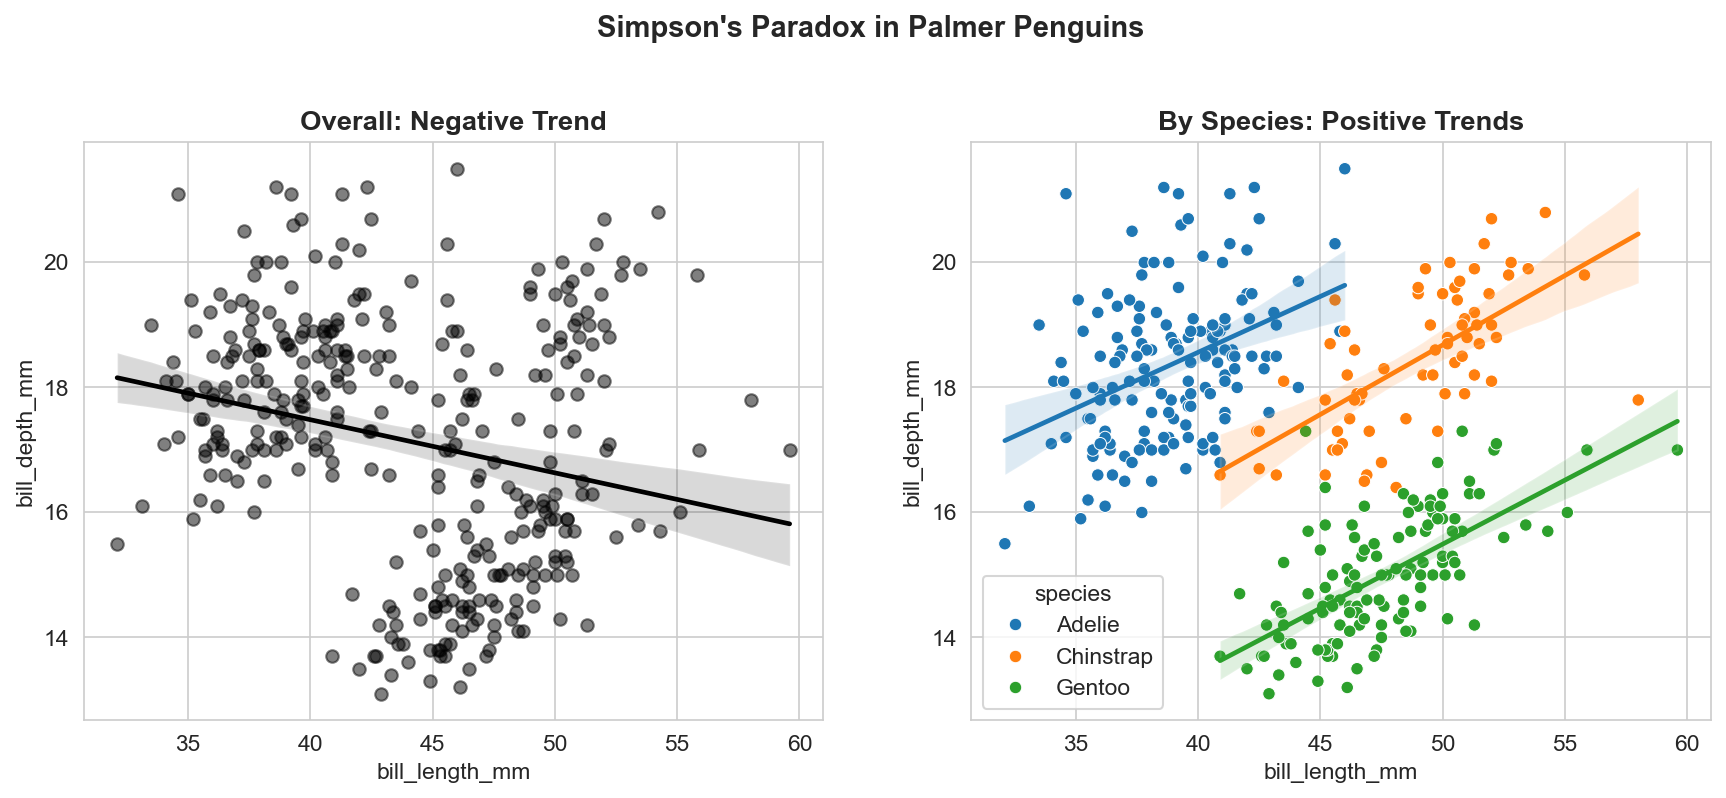

In [5]:
# ============================================================
# 1. Palmer Penguins (Continuous Data)
# ============================================================
# The Paradox: Overall, longer bills appear to be shallower (negative correlation).
# But within EVERY species, longer bills are deeper (positive correlation).

import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins").dropna(subset=["bill_length_mm", "bill_depth_mm", "species"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall trend
sns.regplot(data=penguins, x="bill_length_mm", y="bill_depth_mm",
            color="black", scatter_kws={'alpha':0.5}, ax=axes[0])
axes[0].set_title("Overall: Negative Trend", fontweight='bold')

# Grouped trend
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", ax=axes[1])
for species in penguins['species'].unique():
    subset = penguins[penguins['species'] == species]
    sns.regplot(data=subset, x="bill_length_mm", y="bill_depth_mm", scatter=False, ax=axes[1])

axes[1].set_title("By Species: Positive Trends", fontweight='bold')
plt.suptitle("Simpson's Paradox in Palmer Penguins", fontsize=14, fontweight='bold', y=1.05)
plt.show()

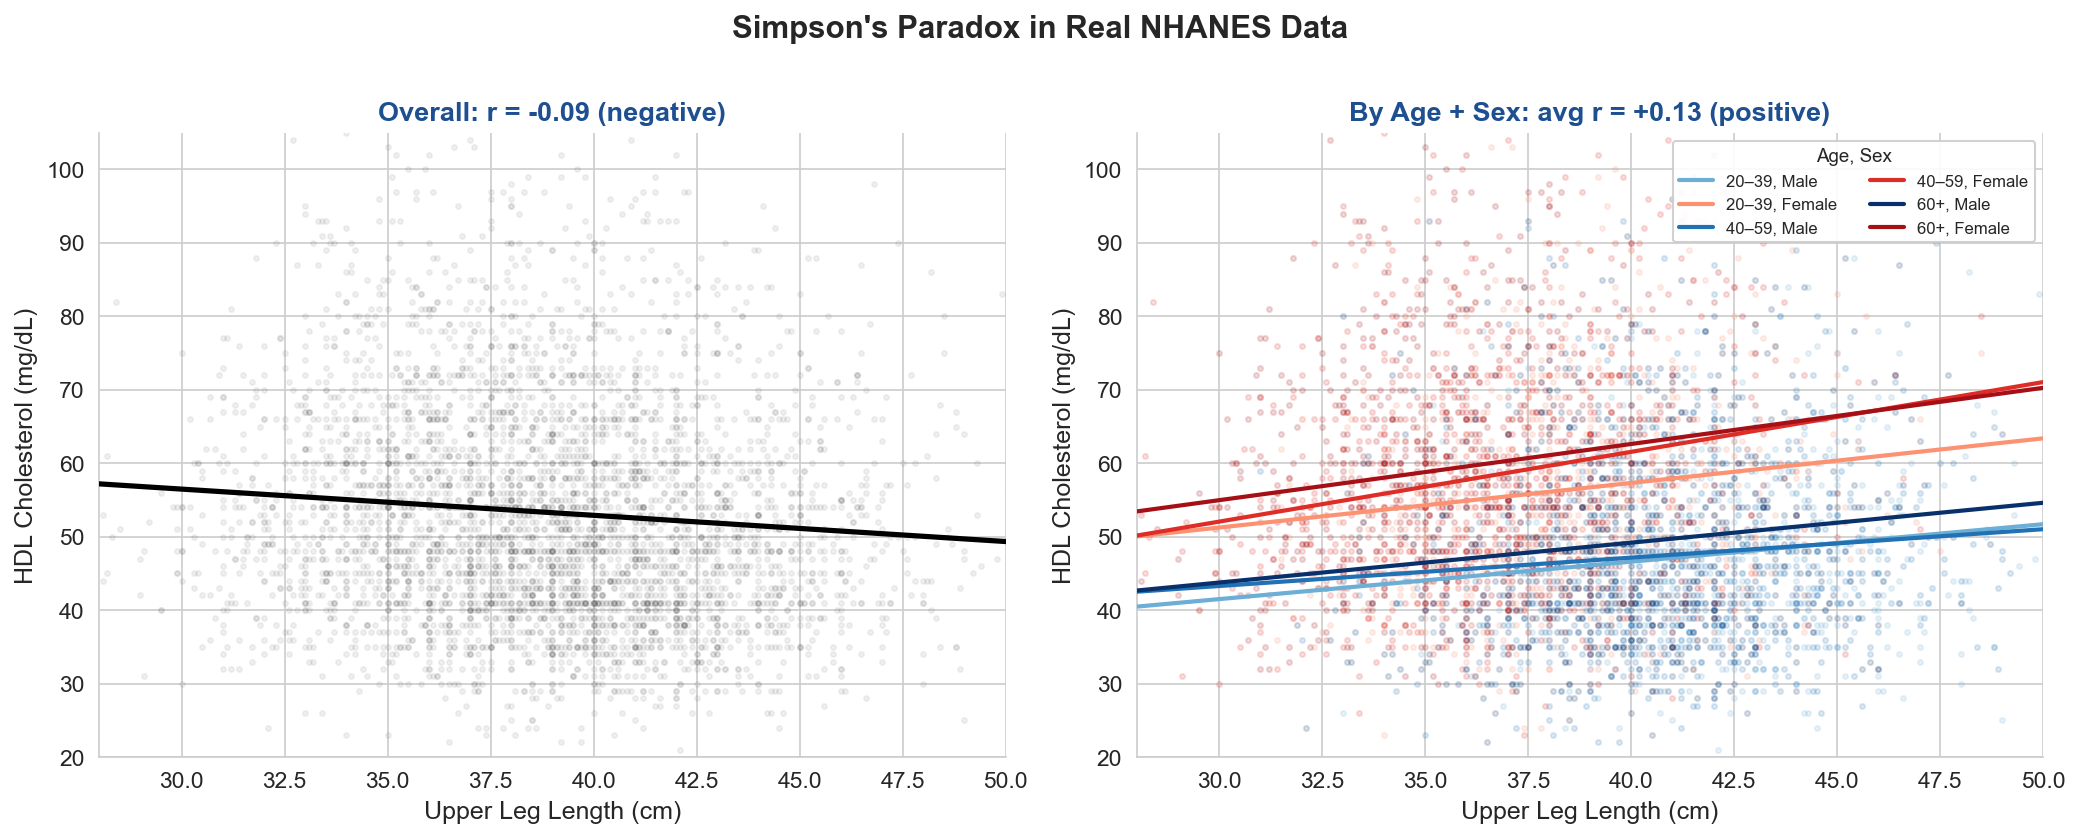


Overall correlation: r = -0.088 (longer legs → lower HDL)
Within-group average: r = +0.127 (longer legs → higher HDL)

Why? Men have longer legs AND lower HDL than women.
Age also confounds: older adults have shorter legs and different HDL levels.
Aggregating across age+sex groups reverses the within-group relationship.

N = 4592 adults. Data: NHANES 2017-2018 (real, no simulation).


In [6]:
# ============================================================
# Simpson's Paradox in NHANES: Leg Length vs HDL Cholesterol
# ============================================================
# LECTURE FIGURE — can be used on the Simpson's Paradox slide
#
# Overall: longer legs correlate with LOWER HDL (r ≈ -0.12)
# Within age+sex groups: longer legs correlate with HIGHER HDL
# Confounder: Men have longer legs AND lower HDL than women.
#             Older adults have shorter legs AND different HDL.

if 'nhanes' in locals():
    df_n = nhanes[nhanes['RIDAGEYR'] >= 20].copy()
    df_n = df_n.dropna(subset=['BMXLEG', 'LBDHDD', 'RIDAGEYR', 'RIAGENDR'])
    df_n['Age Group'] = pd.cut(df_n['RIDAGEYR'], bins=[20, 40, 60, 100],
                                labels=['20–39', '40–59', '60+'])
    df_n['Sex'] = df_n['RIAGENDR'].map({1: 'Male', 2: 'Female'})
    df_n['Subgroup'] = df_n['Age Group'].astype(str) + ', ' + df_n['Sex']
    df_n = df_n.dropna(subset=['Subgroup'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # --- Left: Overall trend ---
    ax = axes[0]
    ax.scatter(df_n['BMXLEG'], df_n['LBDHDD'], alpha=0.08, s=6, color='#555555', rasterized=True)
    z = np.polyfit(df_n['BMXLEG'].values, df_n['LBDHDD'].values, 1)
    x_line = np.linspace(df_n['BMXLEG'].min(), df_n['BMXLEG'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color='black', linewidth=2.5, zorder=5)
    r_overall = df_n[['BMXLEG', 'LBDHDD']].corr().iloc[0, 1]
    ax.set_xlabel('Upper Leg Length (cm)', fontsize=12)
    ax.set_ylabel('HDL Cholesterol (mg/dL)', fontsize=12)
    ax.set_title(f'Overall: r = {r_overall:.2f} (negative)', fontsize=13,
                 fontweight='bold', color=COLUMBIA)
    ax.set_ylim(20, 105)
    ax.set_xlim(28, 50)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- Right: Stratified by age + sex ---
    ax = axes[1]
    subgroups = ['20–39, Male', '20–39, Female', '40–59, Male', '40–59, Female',
                 '60+, Male', '60+, Female']
    # Use a clean 6-color palette: blues for males, reds for females, darker = older
    colors = {
        '20–39, Male': '#6BAED6', '40–59, Male': '#2171B5', '60+, Male': '#08306B',
        '20–39, Female': '#FC9272', '40–59, Female': '#DE2D26', '60+, Female': '#A50F15',
    }
    r_within = []
    for sg in subgroups:
        mask = df_n['Subgroup'] == sg
        sub = df_n[mask]
        if len(sub) < 30:
            continue
        c = colors[sg]
        ax.scatter(sub['BMXLEG'], sub['LBDHDD'], alpha=0.15, s=6, color=c, rasterized=True)
        z_sub = np.polyfit(sub['BMXLEG'].values, sub['LBDHDD'].values, 1)
        ax.plot(x_line, np.polyval(z_sub, x_line), color=c, linewidth=2, label=sg, zorder=5)
        r_sub = sub[['BMXLEG', 'LBDHDD']].corr().iloc[0, 1]
        r_within.append(r_sub)

    avg_r = np.mean(r_within)
    ax.set_xlabel('Upper Leg Length (cm)', fontsize=12)
    ax.set_ylabel('HDL Cholesterol (mg/dL)', fontsize=12)
    ax.set_title(f'By Age + Sex: avg r = {avg_r:+.2f} (positive)', fontsize=13,
                 fontweight='bold', color=COLUMBIA)
    ax.legend(fontsize=8, loc='upper right', framealpha=0.9, ncol=2,
              title='Age, Sex', title_fontsize=9)
    ax.set_ylim(20, 105)
    ax.set_xlim(28, 50)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.suptitle("Simpson's Paradox in Real NHANES Data",
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("figures/fig_simpsons_nhanes.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nOverall correlation: r = {r_overall:.3f} (longer legs → lower HDL)")
    print(f"Within-group average: r = {avg_r:+.3f} (longer legs → higher HDL)")
    print(f"\nWhy? Men have longer legs AND lower HDL than women.")
    print(f"Age also confounds: older adults have shorter legs and different HDL levels.")
    print(f"Aggregating across age+sex groups reverses the within-group relationship.")
    print(f"\nN = {len(df_n)} adults. Data: NHANES 2017-2018 (real, no simulation).")
else:
    print("NHANES data not loaded — skipping this example.")


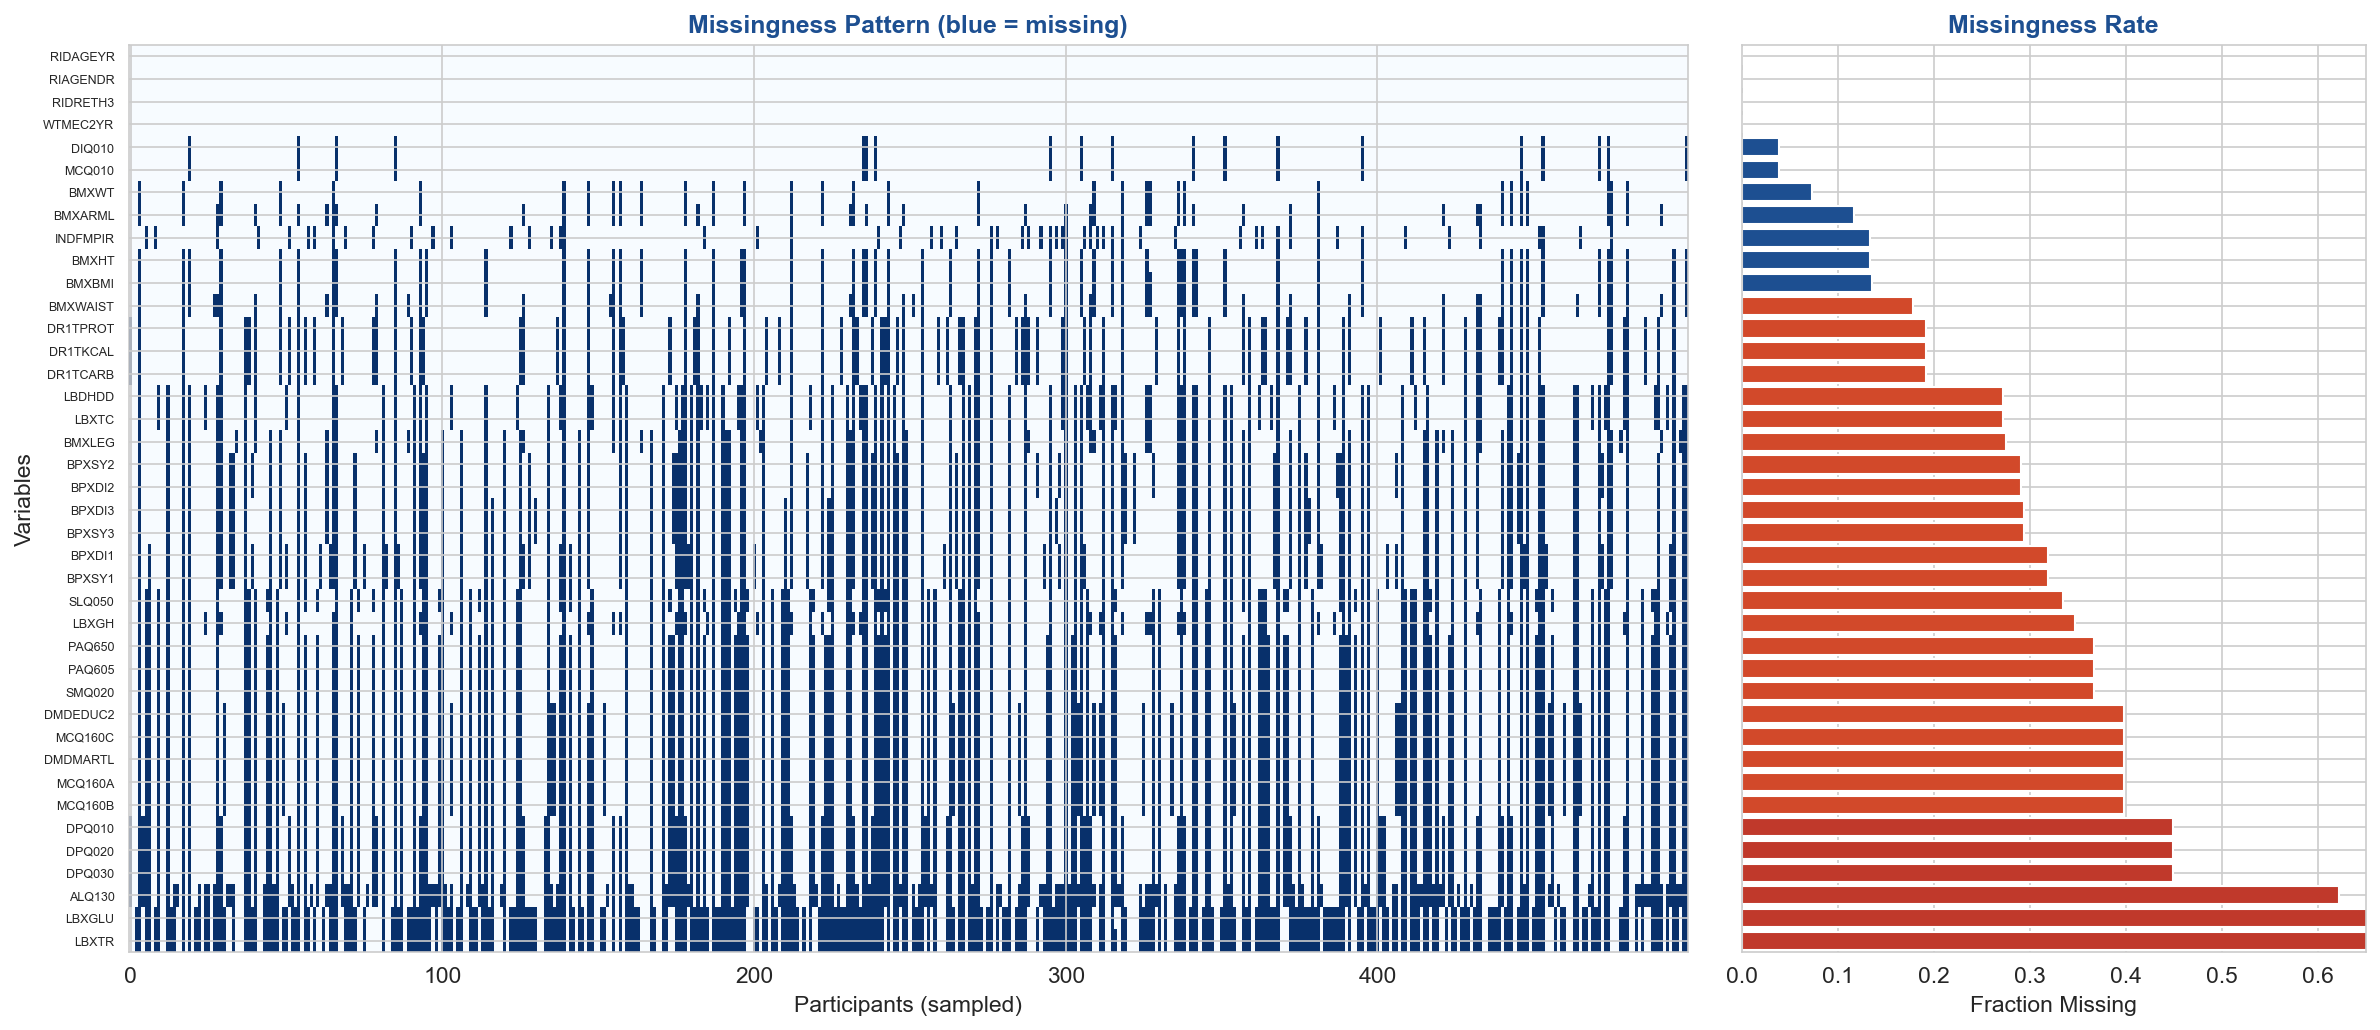

Saved figures/fig1_nhanes_missingness.png

40 variables shown. Missingness ranges from 0.0% to 69.4%.


In [7]:
# ============================================================
# Figure 1: NHANES Missingness Heatmap & Variable Types
# ============================================================
# Show missingness structure — real NHANES has module-level gaps

# Use all columns (excluding SEQN which is an ID)
show_cols = [c for c in nhanes.columns if c != "SEQN" and nhanes[c].notna().mean() > 0.01]

# Sort by missingness rate (ascending = least missing at bottom)
miss_rates = nhanes[show_cols].isnull().mean()
show_cols_sorted = miss_rates.sort_values(ascending=True).index.tolist()

# Adding sharey=True forces them to share the exact same y-axis
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [2.5, 1]}, sharey=True)

# Left: missingness heatmap (sample rows for visibility)
ax = axes[0]
np.random.seed(0)
sample_idx = np.sort(np.random.choice(len(nhanes), min(500, len(nhanes)), replace=False))
miss_matrix = nhanes.iloc[sample_idx][show_cols_sorted].isnull().astype(int).values

ax.imshow(miss_matrix.T, aspect='auto', cmap='Blues', interpolation='none', vmin=0, vmax=1)
ax.set_xlabel("Participants (sampled)", fontsize=11)
ax.set_ylabel("Variables", fontsize=11)
ax.set_title("Missingness Pattern (blue = missing)", fontsize=12, fontweight='bold', color=COLUMBIA)

# Label every variable on y-axis
ax.set_yticks(range(len(show_cols_sorted)))
ax.set_yticklabels(show_cols_sorted, fontsize=6)

# Right: missingness rate per variable (horizontal bar chart)
ax = axes[1]
rates_sorted = miss_rates[show_cols_sorted].values
colors_bar = [COLUMBIA if r < 0.15 else ACCENT if r < 0.40 else '#C0392B' for r in rates_sorted]
ax.barh(range(len(show_cols_sorted)), rates_sorted, color=colors_bar)

ax.set_xlabel("Fraction Missing", fontsize=11)
ax.set_title("Missingness Rate", fontsize=12, fontweight='bold', color=COLUMBIA)
ax.set_xlim(0, 0.65)

# Force strict alignment to the imshow grid bounds (N-0.5 to -0.5 is top-down)
axes[0].set_ylim(len(show_cols_sorted) - 0.5, -0.5)

plt.tight_layout()
# Bring plots closer together to make alignment clear
fig.subplots_adjust(wspace=0.05)

plt.savefig("figures/fig1_nhanes_missingness.png")
plt.show()
print("Saved figures/fig1_nhanes_missingness.png")
print(f"\n{len(show_cols_sorted)} variables shown. Missingness ranges from "
      f"{miss_rates.min():.1%} to {miss_rates.max():.1%}.")


---

## Figure 3: Kaplan-Meier Survival Curves

**LECTURE FIGURE** (slide: "K-M on Real Data: Population and Subgroups")

NCCTG Lung Cancer dataset (lifelines built-in). **Left panel:** population-level K-M curve with median survival annotation. **Right panel:** stratified by sex, revealing subgroup differences via log-rank test. The point is *how to read* survival curves — step functions, censoring marks, confidence bands — not a claim about the specific sex effect.


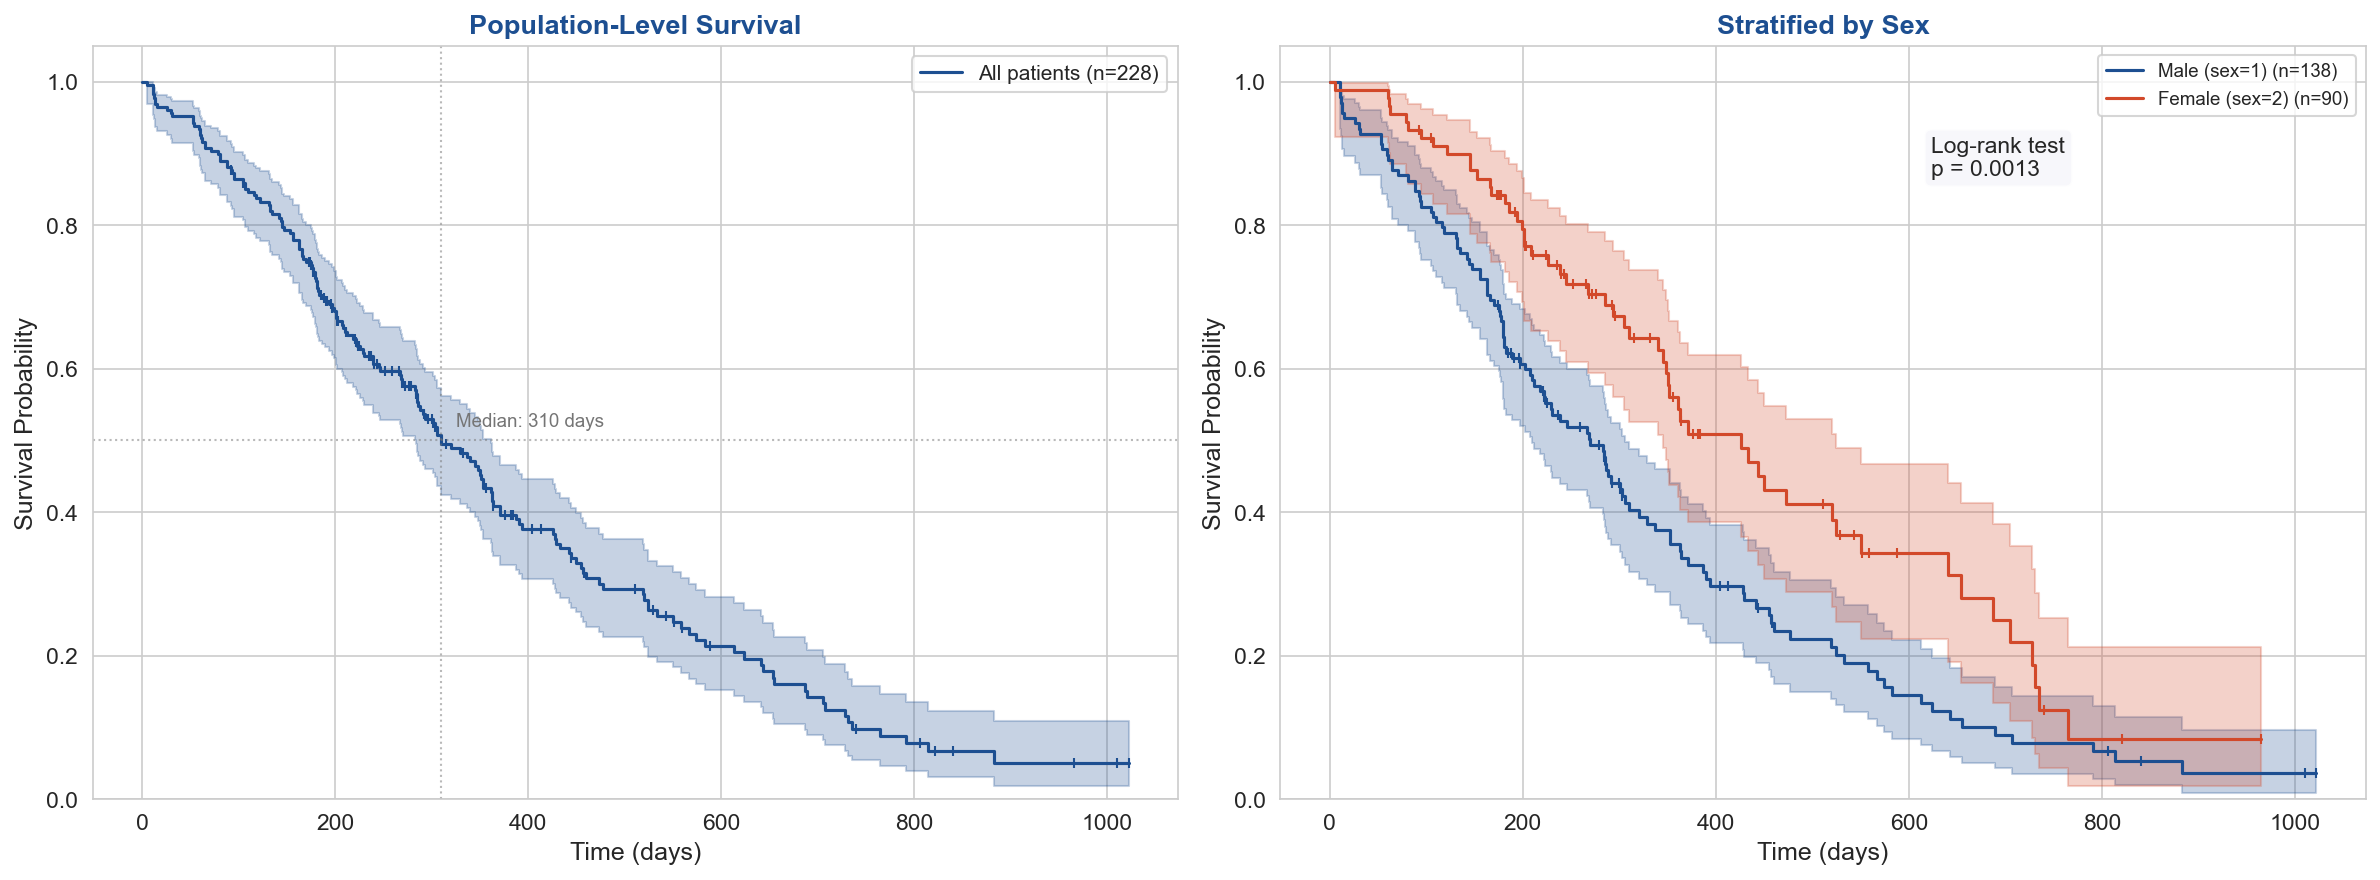

Saved figures/fig3_kaplan_meier.png

Population median survival: 310 days
Log-rank p-value (sex): 0.0013


In [8]:
# ============================================================
# Figure 3: Kaplan-Meier Curves — Population Level, Then Subgroups
# ============================================================
# Key pedagogical point: KM gives a population-level survival estimate.
# You can then subdivide into subgroups to reveal differences.
# At the individual level, we interpret the curve probabilistically.

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

kmf = KaplanMeierFitter()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left panel: Population-level curve ---
ax = axes[0]
T_all = lung["time"]
E_all = lung["status"] == 1  # status=1 = death in lifelines lung dataset

kmf.fit(T_all, event_observed=E_all, label=f"All patients (n={len(T_all)})")
kmf.plot_survival_function(ax=ax, color=COLUMBIA, ci_show=True, show_censors=True,
                            censor_styles={"ms": 5, "marker": "|"})

ax.set_xlabel("Time (days)", fontsize=12)
ax.set_ylabel("Survival Probability", fontsize=12)
ax.set_title("Population-Level Survival", fontsize=13, fontweight='bold', color=COLUMBIA)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)

# Add median survival annotation
median_surv = kmf.median_survival_time_
if np.isfinite(median_surv):
    ax.axhline(0.5, color=GRAY, linestyle=':', linewidth=1, alpha=0.5)
    ax.axvline(median_surv, color=GRAY, linestyle=':', linewidth=1, alpha=0.5)
    ax.text(median_surv + 15, 0.52, f"Median: {median_surv:.0f} days",
            fontsize=9, color=GRAY)

# --- Right panel: Stratified by sex ---
ax = axes[1]
groups = sorted(lung["sex"].unique())
colors = [COLUMBIA, ACCENT]
labels = {1: "Male (sex=1)", 2: "Female (sex=2)"}

for i, group in enumerate(groups):
    mask = lung["sex"] == group
    T = lung.loc[mask, "time"]
    E = lung.loc[mask, "status"] == 1
    n_g = mask.sum()
    kmf.fit(T, event_observed=E, label=f"{labels.get(group, f'Sex {group}')} (n={n_g})")
    kmf.plot_survival_function(ax=ax, color=colors[i], ci_show=True, show_censors=True,
                                censor_styles={"ms": 5, "marker": "|"})

# Log-rank test
mask1 = lung["sex"] == groups[0]
result = logrank_test(
    lung.loc[mask1, "time"], lung.loc[~mask1, "time"],
    lung.loc[mask1, "status"] == 1, lung.loc[~mask1, "status"] == 1
)

ax.set_xlabel("Time (days)", fontsize=12)
ax.set_ylabel("Survival Probability", fontsize=12)
ax.set_title("Stratified by Sex", fontsize=13, fontweight='bold', color=COLUMBIA)
ax.text(0.60, 0.88, f"Log-rank test\np = {result.p_value:.4f}",
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=LIGHT_BG, alpha=0.8))
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("figures/fig3_kaplan_meier.png")
plt.show()
print("Saved figures/fig3_kaplan_meier.png")
print(f"\nPopulation median survival: {median_surv:.0f} days")
print(f"Log-rank p-value (sex): {result.p_value:.4f}")


---

## Figure 4: Cox Proportional Hazards — Forest Plot & Diagnostics

**LECTURE FIGURE** (slide: "Cox PH")

Fit CoxPH on the GBSG2 (German Breast Cancer Study Group) RCT data. Show hazard ratio forest plot and Schoenfeld residuals.


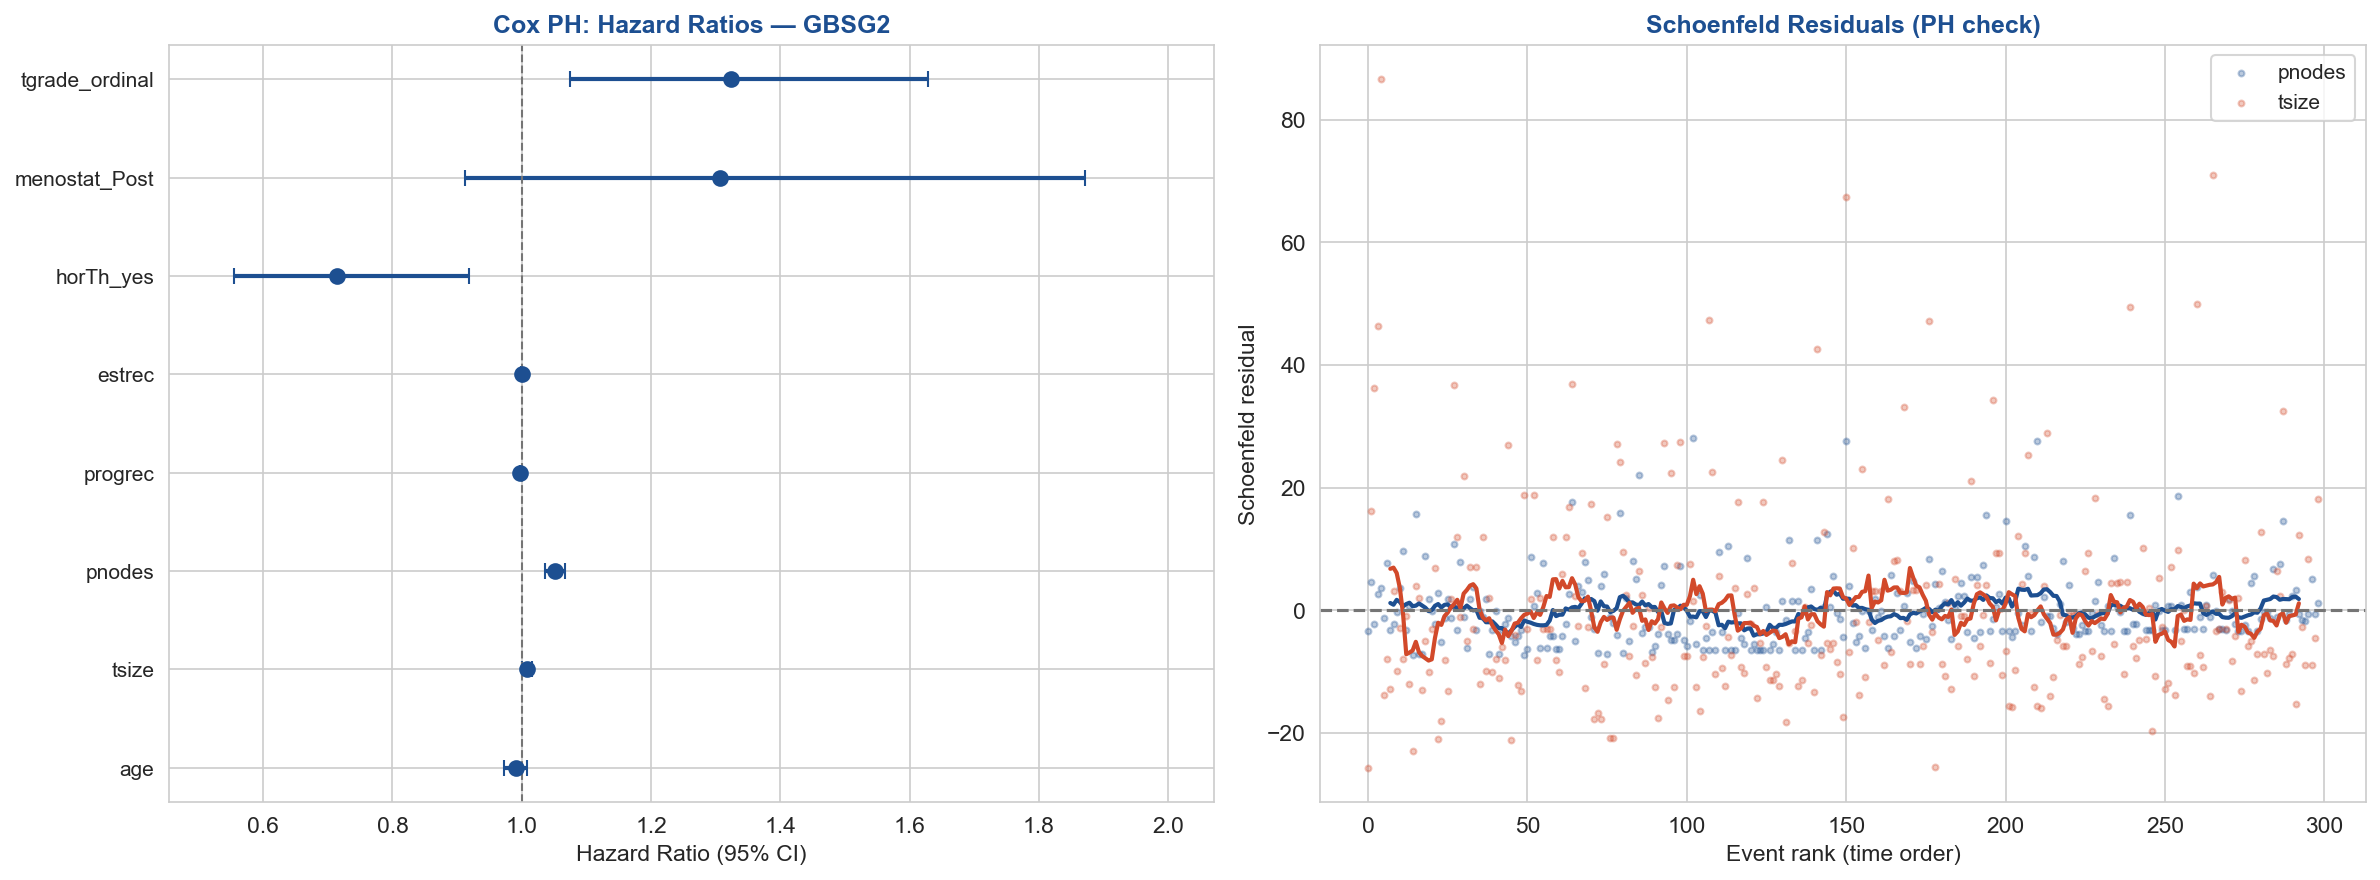

Saved figures/fig4_cox_forest.png

Cox PH Summary:


<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'time'
                event col = 'cens'
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1737.17
         time fit was run = 2026-04-30 04:30:21 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
age            -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
tsize           0.01      1.01      0.00           -0.00            0.02                1.00                1.02
pnodes          0.05      1.05      0.01            0.04            0.06                1.04                1.07
progrec        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
estrec          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
horTh_yes      -0.34      0.71      0.13           -0.59           -0.08                0.55                0.92
menostat_Post   0.27      1.31      0.18           -0.09            0.63                0.91                1.87
tgrade_ordinal  0.28      1.32      0.11            0.07            0.49                1.08                1.63

                cmp to     z      p  -log2(p)
covariate                                    
age               0.00 -1.01   0.31      1.68
tsize             0.00  1.95   0.05      4.30
pnodes            0.00  6.73 <0.005     35.82
progrec           0.00 -3.89 <0.005     13.26
estrec            0.00  0.37   0.71      0.50
horTh_yes         0.00 -2.61   0.01      6.81
menostat_Post     0.00  1.46   0.14      2.79
tgrade_ordinal    0.00  2.64   0.01      6.93
---
Concordance = 0.69
Partial AIC = 3490.35
log-likelihood ratio test = 101.86 on 8 df
-log2(p) of ll-ratio test = 58.96

In [9]:
# ============================================================
# Figure 4: Cox PH Forest Plot + Schoenfeld Residuals
# ============================================================
from lifelines import CoxPHFitter

# Prepare GBSG2 data
gbsg2_model = gbsg2.copy()

# Encode categorical variables
gbsg2_model["horTh_yes"] = (gbsg2_model["horTh"] == "yes").astype(int)
gbsg2_model["menostat_Post"] = (gbsg2_model["menostat"] == "Post").astype(int)
gbsg2_model["tgrade_ordinal"] = gbsg2_model["tgrade"].map({"I": 1, "II": 2, "III": 3})

covariates = ["age", "tsize", "pnodes", "progrec", "estrec", "horTh_yes", "menostat_Post", "tgrade_ordinal"]
gbsg2_clean = gbsg2_model[covariates + ["time", "cens"]].dropna()

cph = CoxPHFitter()
cph.fit(gbsg2_clean, duration_col="time", event_col="cens")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: forest plot
ax = axes[0]
summary = cph.summary
hr = np.exp(summary["coef"])
ci_low = np.exp(summary["coef lower 95%"])
ci_high = np.exp(summary["coef upper 95%"])
y_pos = range(len(hr))

ax.errorbar(hr.values, y_pos, xerr=[hr.values - ci_low.values, ci_high.values - hr.values],
            fmt='o', color=COLUMBIA, capsize=4, markersize=7, linewidth=2)
ax.axvline(1.0, color=GRAY, linestyle='--', linewidth=1)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(hr.index, fontsize=10)
ax.set_xlabel("Hazard Ratio (95% CI)", fontsize=11)
ax.set_title("Cox PH: Hazard Ratios — GBSG2", fontsize=12, fontweight='bold', color=COLUMBIA)
ax.set_xlim(max(0, ci_low.min() - 0.1), min(ci_high.max() + 0.2, 3.0))

# Right: Schoenfeld residuals for top 2 covariates
ax = axes[1]
# Use lifelines check_assumptions silently, or plot manually
try:
    schoenfeld = cph.compute_residuals(gbsg2_clean, kind="schoenfeld")
    for j, col in enumerate(["pnodes", "tsize"]):
        color = [COLUMBIA, ACCENT][j]
        ax.scatter(range(len(schoenfeld)), schoenfeld[col].values, alpha=0.3, s=8, color=color, label=col)
        # LOESS-like: rolling mean
        window = max(10, len(schoenfeld)//20)
        rolling = pd.Series(schoenfeld[col].values).rolling(window, center=True).mean()
        ax.plot(range(len(rolling)), rolling.values, color=color, linewidth=2)
    ax.axhline(0, color=GRAY, linestyle='--')
    ax.set_xlabel("Event rank (time order)", fontsize=11)
    ax.set_ylabel("Schoenfeld residual", fontsize=11)
    ax.set_title("Schoenfeld Residuals (PH check)", fontsize=12, fontweight='bold', color=COLUMBIA)
    ax.legend(fontsize=10)
except Exception as e:
    ax.text(0.5, 0.5, f"Schoenfeld plot unavailable:\n{e}", transform=ax.transAxes,
            ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.savefig("figures/fig4_cox_forest.png")
plt.show()
print("Saved figures/fig4_cox_forest.png")
print("\nCox PH Summary:")
cph.print_summary()


---

## Figure 5: DeepSurv vs. Cox PH

**APPENDIX FIGURE** (in slide appendix, not main deck)

DeepSurv: 2-layer neural network using Cox partial likelihood loss. On GBSG2 (686 patients, 8 clinical features), DeepSurv (C=0.698) slightly underperforms Cox (C=0.711). Expected: small n, few well-understood covariates. Single-seed didactic demo. DeepSurv's advantages emerge with high-dimensional inputs and larger datasets.


Cox PH C-index (val): 0.7109
DeepSurv C-index (val, final): 0.6985


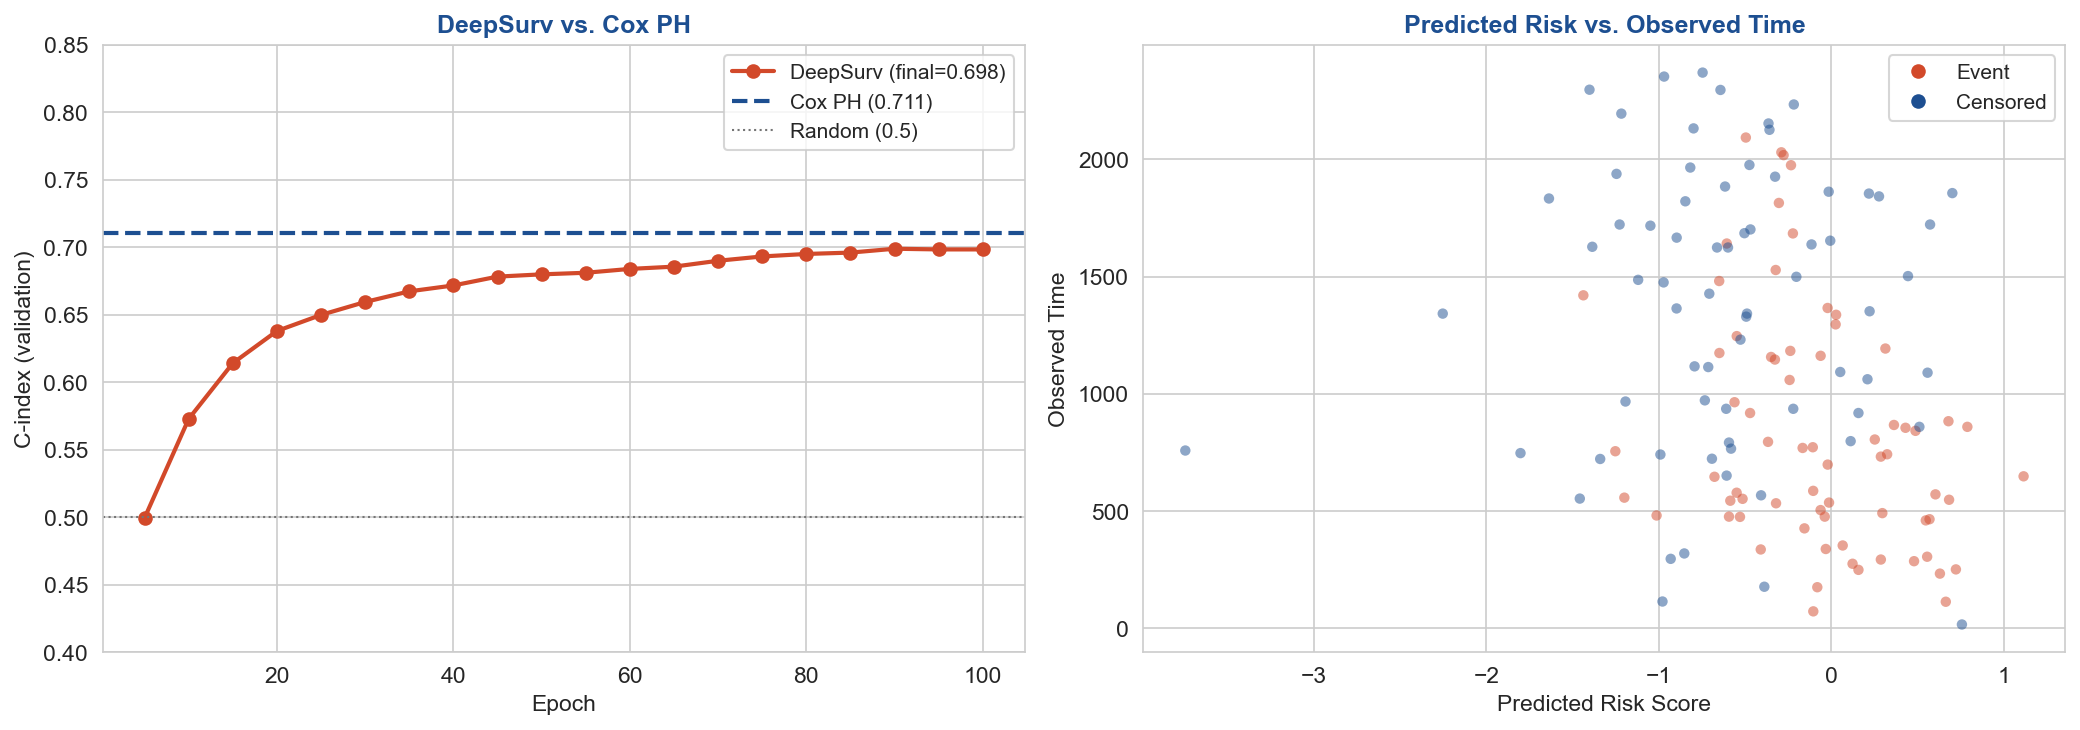

Saved figures/fig5_deepsurv_comparison.png


In [10]:
# ============================================================
# Figure 5: DeepSurv vs. Cox — C-index Comparison
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from lifelines.utils import concordance_index

# Prepare data
X_cols = ["age", "tsize", "pnodes", "progrec", "estrec", "horTh_yes", "menostat_Post", "tgrade_ordinal"]
df = gbsg2_clean.copy()

# Train/val split (patient-level, 80/20)
np.random.seed(42)
torch.manual_seed(42)  # Added for PyTorch reproducibility
idx = np.random.permutation(len(df))
split = int(0.8 * len(df))
train_idx, val_idx = idx[:split], idx[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(df.iloc[train_idx][X_cols].values)
X_val = scaler.transform(df.iloc[val_idx][X_cols].values)
T_train = df.iloc[train_idx]["time"].values.astype(np.float32)
E_train = df.iloc[train_idx]["cens"].values.astype(np.float32)
T_val = df.iloc[val_idx]["time"].values.astype(np.float32)
E_val = df.iloc[val_idx]["cens"].values.astype(np.float32)

# DeepSurv: 2-layer MLP with Cox partial likelihood
class DeepSurv(nn.Module):
    def __init__(self, in_features, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def cox_partial_likelihood_loss(risk_scores, times, events):
    """Negative Cox partial log-likelihood."""
    sorted_idx = torch.argsort(times, descending=True)
    risk_scores = risk_scores[sorted_idx]
    events = events[sorted_idx]
    log_cumsum = torch.logcumsumexp(risk_scores, dim=0)
    loss = -torch.mean((risk_scores - log_cumsum) * events)
    return loss

model = DeepSurv(len(X_cols), hidden=32)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
T_train_t = torch.tensor(T_train, dtype=torch.float32)
E_train_t = torch.tensor(E_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)

# Train
deepsurv_cindices = []
cox_cindex_val = concordance_index(T_val, -cph.predict_partial_hazard(df.iloc[val_idx][X_cols + ["time", "cens"]]).values, E_val)

for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    risk = model(X_train_t)
    loss = cox_partial_likelihood_loss(risk, T_train_t, E_train_t)
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            val_risk = model(X_val_t).numpy()
        ci = concordance_index(T_val, -val_risk, E_val)
        deepsurv_cindices.append((epoch, ci))

print(f"Cox PH C-index (val): {cox_cindex_val:.4f}")
print(f"DeepSurv C-index (val, final): {deepsurv_cindices[-1][1]:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: C-index learning curve
ax = axes[0]
epochs_ds, cindices_ds = zip(*deepsurv_cindices)
ax.plot(epochs_ds, cindices_ds, 'o-', color=ACCENT, label=f"DeepSurv (final={cindices_ds[-1]:.3f})", linewidth=2)
ax.axhline(cox_cindex_val, color=COLUMBIA, linestyle='--', linewidth=2, label=f"Cox PH ({cox_cindex_val:.3f})")
ax.axhline(0.5, color=GRAY, linestyle=':', linewidth=1, label="Random (0.5)")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("C-index (validation)", fontsize=11)
ax.set_title("DeepSurv vs. Cox PH", fontsize=12, fontweight='bold', color=COLUMBIA)
ax.legend(fontsize=10)
ax.set_ylim(0.4, 0.85)

# Right: Predicted risk vs. observed time
ax = axes[1]
model.eval()
with torch.no_grad():
    val_risk_final = model(X_val_t).numpy()
colors_scatter = [ACCENT if e == 1 else COLUMBIA for e in E_val]
ax.scatter(val_risk_final, T_val, c=colors_scatter, alpha=0.5, s=25, edgecolors='none')
ax.set_xlabel("Predicted Risk Score", fontsize=11)
ax.set_ylabel("Observed Time", fontsize=11)
ax.set_title("Predicted Risk vs. Observed Time", fontsize=12, fontweight='bold', color=COLUMBIA)
# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ACCENT, markersize=8, label='Event'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor=COLUMBIA, markersize=8, label='Censored')]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig("figures/fig5_deepsurv_comparison.png")
plt.show()
print("Saved figures/fig5_deepsurv_comparison.png")


---

## Figure 6: Propensity Score Adjustment

**APPENDIX FIGURE** (full treatment Thursday L24)

**Why simulation is necessary here:** To demonstrate that propensity score adjustment *works*, you need to know the true treatment effect — so you can compare the naïve (biased) estimate to the PS-adjusted estimate and show that adjustment recovers the truth. In real observational data, the true effect is *never known* — that's the whole point of causal inference. Every PS tutorial in the literature uses simulation for this reason.


True effect:       -2.00
Naïve estimate:    1.27
IPTW estimate:     -2.26
Matched estimate:  -2.08


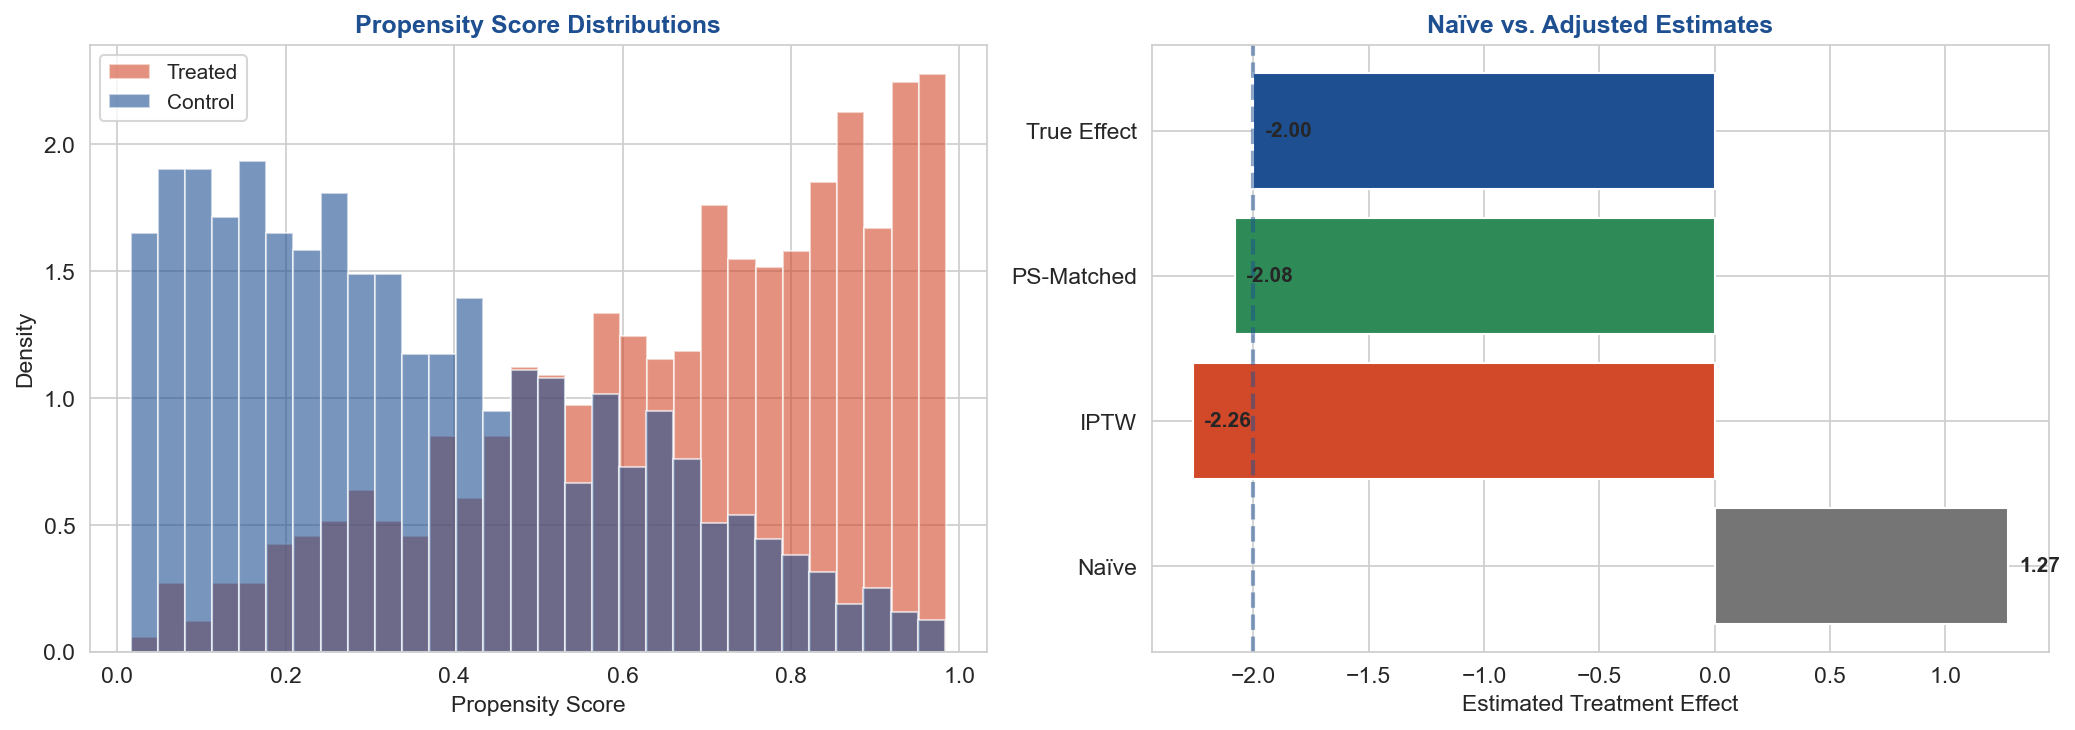

Saved figures/fig6_propensity_scores.png


In [11]:
# ============================================================
# Figure 6: Propensity Score Adjustment Demo
# ============================================================
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
n = 2000

# Confounder: disease severity (0-10)
severity = np.random.normal(5, 2, n).clip(0, 10)

# Treatment assignment: sicker patients more likely to get treatment
p_treat = 1 / (1 + np.exp(-(severity - 5) * 0.8))
treatment = np.random.binomial(1, p_treat)

# Outcome: lower is better. Treatment helps (true effect = -2), but severity hurts
true_effect = -2.0
outcome = severity * 1.5 + treatment * true_effect + np.random.normal(0, 2, n)

# Naïve estimate (ignoring confounding)
naive_effect = outcome[treatment == 1].mean() - outcome[treatment == 0].mean()

# Propensity score model
ps_model = LogisticRegression()
ps_model.fit(severity.reshape(-1, 1), treatment)
ps = ps_model.predict_proba(severity.reshape(-1, 1))[:, 1]

# IPTW (inverse propensity weighting)
weights = np.where(treatment == 1, 1/ps, 1/(1-ps))
iptw_effect = (np.average(outcome, weights=weights * treatment) -
               np.average(outcome, weights=weights * (1-treatment)))

# PS matching (simple nearest-neighbor)
treated_idx = np.where(treatment == 1)[0]
control_idx = np.where(treatment == 0)[0]
matched_outcomes_t, matched_outcomes_c = [], []
for i in treated_idx:
    dists = np.abs(ps[control_idx] - ps[i])
    best = control_idx[np.argmin(dists)]
    matched_outcomes_t.append(outcome[i])
    matched_outcomes_c.append(outcome[best])
matched_effect = np.mean(matched_outcomes_t) - np.mean(matched_outcomes_c)

print(f"True effect:       {true_effect:.2f}")
print(f"Naïve estimate:    {naive_effect:.2f}")
print(f"IPTW estimate:     {iptw_effect:.2f}")
print(f"Matched estimate:  {matched_effect:.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PS distributions
ax = axes[0]
ax.hist(ps[treatment == 1], bins=30, alpha=0.6, color=ACCENT, label="Treated", density=True)
ax.hist(ps[treatment == 0], bins=30, alpha=0.6, color=COLUMBIA, label="Control", density=True)
ax.set_xlabel("Propensity Score", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Propensity Score Distributions", fontsize=12, fontweight='bold', color=COLUMBIA)
ax.legend(fontsize=10)

# Right: Effect estimates
ax = axes[1]
estimates = [naive_effect, iptw_effect, matched_effect, true_effect]
labels = ["Naïve", "IPTW", "PS-Matched", "True Effect"]
colors = [GRAY, ACCENT, GREEN, COLUMBIA]
bars = ax.barh(labels, estimates, color=colors)
ax.axvline(true_effect, color=COLUMBIA, linestyle='--', linewidth=2, alpha=0.5)
ax.set_xlabel("Estimated Treatment Effect", fontsize=11)
ax.set_title("Naïve vs. Adjusted Estimates", fontsize=12, fontweight='bold', color=COLUMBIA)
for bar, val in zip(bars, estimates):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f"{val:.2f}",
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("figures/fig6_propensity_scores.png")
plt.show()
print("Saved figures/fig6_propensity_scores.png")


---

## Figure 7: Simpson's Paradox — Real Kidney Stone Data

**APPENDIX FIGURE** (also shown as a table in the main slides)

Visualization of the actual Charig et al. (1986) kidney stone data. Left: success rates by treatment and stone size — Treatment A (open surgery) wins in every subgroup but loses overall. Right: sample sizes showing why — open surgery was disproportionately assigned to large (harder) stones. **No simulation needed — this is real published data.**


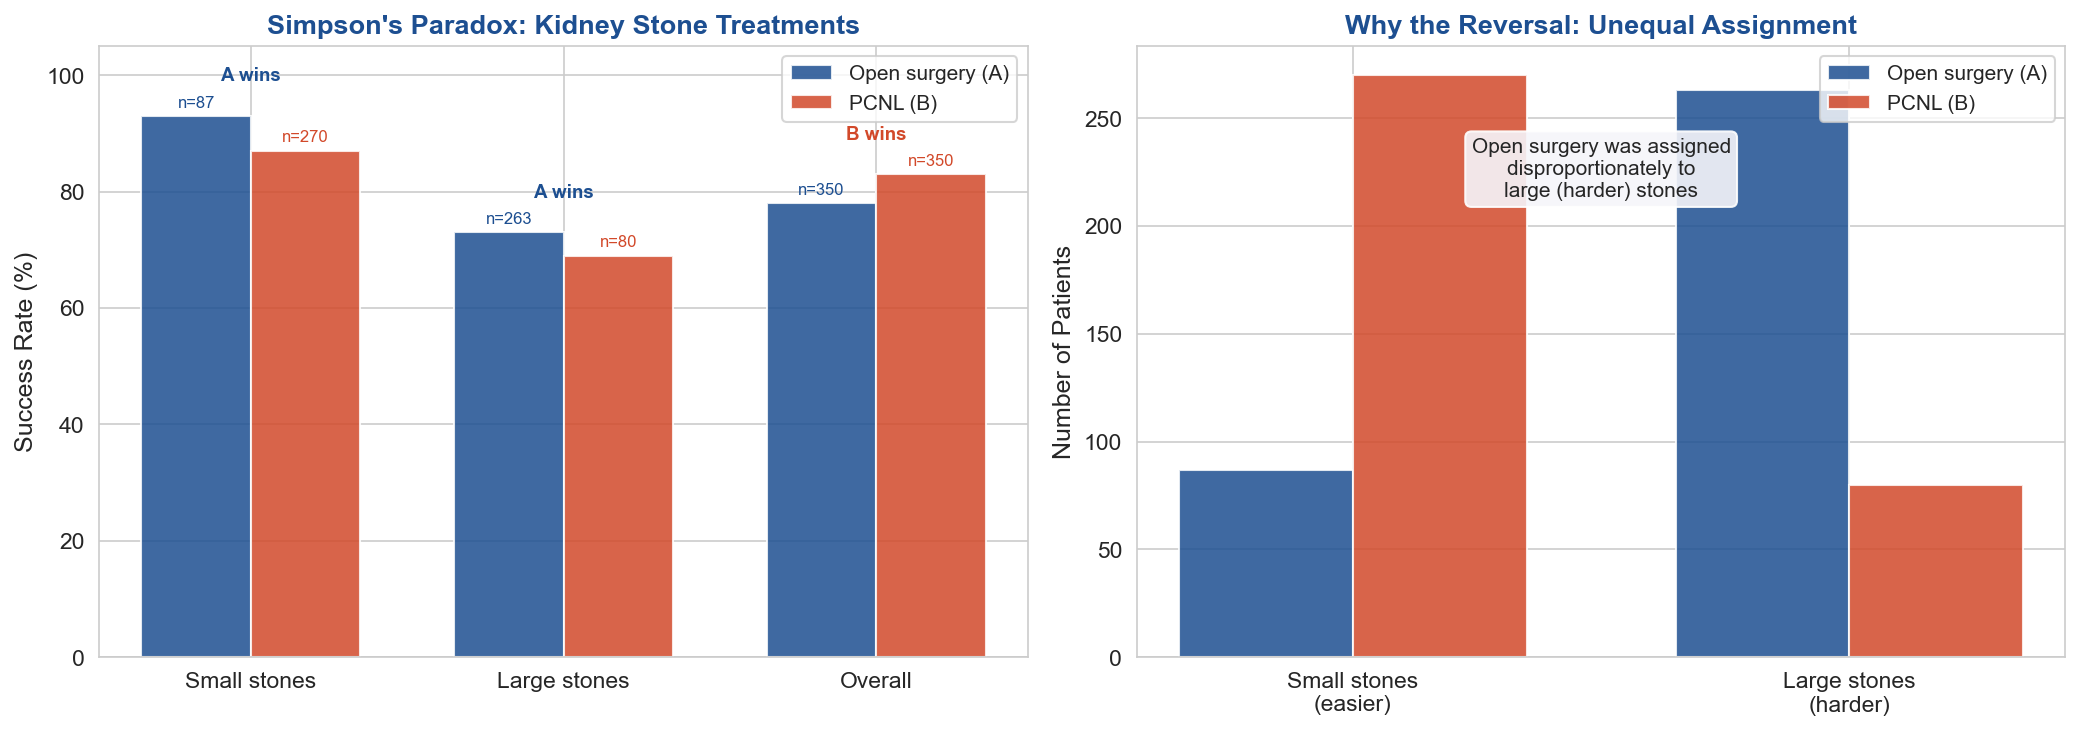

Saved figures/fig7_simpsons_paradox.png

Data source: Charig et al. (1986). BMJ. Real published data — no simulation.


In [12]:
# ============================================================
# Figure 7: Simpson's Paradox — Real Kidney Stone Data (Charig et al., 1986)
# ============================================================
# Real data from the published study. No simulation needed.

# Charig et al. (1986) data
data = {
    'Group': ['Small stones', 'Small stones', 'Large stones', 'Large stones', 'Overall', 'Overall'],
    'Treatment': ['Open surgery (A)', 'PCNL (B)', 'Open surgery (A)', 'PCNL (B)', 'Open surgery (A)', 'PCNL (B)'],
    'Success_rate': [93, 87, 73, 69, 78, 83],
    'N': [87, 270, 263, 80, 350, 350],
}

df_stones = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar chart of success rates
ax = axes[0]
groups = ['Small stones', 'Large stones', 'Overall']
x = np.arange(len(groups))
width = 0.35

rates_A = [93, 73, 78]
rates_B = [87, 69, 83]
n_A = [87, 263, 350]
n_B = [270, 80, 350]

bars_A = ax.bar(x - width/2, rates_A, width, label='Open surgery (A)', color=COLUMBIA, alpha=0.85)
bars_B = ax.bar(x + width/2, rates_B, width, label='PCNL (B)', color=ACCENT, alpha=0.85)

# Add n labels
for bar, n in zip(bars_A, n_A):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={n}', ha='center', va='bottom', fontsize=8, color=COLUMBIA)
for bar, n in zip(bars_B, n_B):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={n}', ha='center', va='bottom', fontsize=8, color=ACCENT)

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title("Simpson's Paradox: Kidney Stone Treatments", fontsize=13, fontweight='bold', color=COLUMBIA)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.axhline(y=0, color='black', linewidth=0.5)

# Add "A wins" / "B wins" annotations
for i, (a, b) in enumerate(zip(rates_A, rates_B)):
    winner = 'A wins' if a > b else 'B wins'
    color = COLUMBIA if a > b else ACCENT
    ax.text(x[i], max(a, b) + 6, winner, ha='center', fontsize=9, fontweight='bold', color=color)

# Right: sample sizes explain the reversal
ax = axes[1]
categories = ['Small stones\n(easier)', 'Large stones\n(harder)']
n_A_sub = [87, 263]
n_B_sub = [270, 80]
x2 = np.arange(len(categories))

ax.bar(x2 - width/2, n_A_sub, width, label='Open surgery (A)', color=COLUMBIA, alpha=0.85)
ax.bar(x2 + width/2, n_B_sub, width, label='PCNL (B)', color=ACCENT, alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Why the Reversal: Unequal Assignment', fontsize=13, fontweight='bold', color=COLUMBIA)
ax.legend(fontsize=10)

# Annotation
ax.text(0.5, 0.85, 'Open surgery was assigned\ndisproportionately to\nlarge (harder) stones',
        transform=ax.transAxes, fontsize=10, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor=LIGHT_BG, alpha=0.9))

plt.tight_layout()
plt.savefig("figures/fig7_simpsons_paradox.png")
plt.show()
print("Saved figures/fig7_simpsons_paradox.png")
print("\nData source: Charig et al. (1986). BMJ. Real published data — no simulation.")


## Discussion Questions

1. **Designed vs. byproduct data:** A hospital wants to study whether a new drug reduces 30-day readmission. They have 5 years of EHR data and could also enroll 200 patients in a pilot trial. What are the trade-offs? When would you use each?

2. **Censoring:** A 3-year cancer survival study has 40% censoring. A colleague says "just drop the censored patients." What's wrong with this? How does it bias the estimate?

3. **External validity:** You build a survival model using UK Biobank data (healthy volunteers, 95% white British). How would you evaluate whether it works for the US population? What specific failure modes would you look for?

4. **Simpson's Paradox:** You find that Hospital A has higher mortality than Hospital B for a specific procedure. Before concluding A is worse, what confounders would you investigate?

5. **Propensity scores:** A colleague adjusts for 50 confounders using propensity scores and declares the treatment effect is causal. What's the key limitation they're ignoring?


---

## Summary

**Part I — Population Health Data:**
1. **NHANES** (real data) illustrates structured survey data with designed sampling and protocol-driven missingness.
2. **Simpson's Paradox** demonstrated with real data: kidney stones (Charig et al.), Palmer Penguins, Berkeley Admissions, and NHANES leg length vs HDL.
3. **Data source determines what you can conclude:** EHR → registries → RCTs trade convenience for rigor.

**Part II — Survival Analysis:**
4. **Kaplan-Meier** estimates population survival; stratifying reveals subgroup differences.
5. **Cox PH** models hazard as a function of covariates — but whether HRs are causal depends on data source, not model.
6. **Beyond Cox:** DeepSurv, random survival forests, discrete-time models — depth helps with high-dimensional inputs and large n.
7. **Propensity scores** (appendix) — preview for Thursday's L24 on causal inference and fairness.

**All data is real** except the propensity score demo (which requires known ground truth by design).
